## The purpose of this experiment to answer these questions
- Can i predict the mask from any new H pose camera?
- The prediction will be better?
- Can i reveal the iddent state sigms?
- Can i reveal the depth map?

## Part 5 Train (neglict ci)

## import libraries

In [1]:

from __future__ import annotations
from pathlib import Path
from typing import List
import platform
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# nerflab imports (make sure your env has nerflab on PYTHONPATH)
from nerflab import Intrinsics, Camera, CFG, load_world, plot_world
from nerflab.io import load_batch_simple, discover_cfg_hash, get_frame_ids_for_case
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row
from nerflab.viz.viz_sigma import viz_sigma_heatmap, viz_sigma_scatter  # adjust import if needed

from torch import nn
from torch.nn.modules import Module
from torch.nn.functional import mse_loss
from torch.optim import SGD
from torch.nn import Sequential, Linear, Softplus

from nerflab.learning.forward_sigma import nerf_opacity, compute_opacity_simple

In [2]:
# gpu_check.py

print(f"PyTorch           : {torch.__version__}")
print(f"Python            : {platform.python_version()} ({sys.executable})")
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA toolkit ver. : {torch.version.cuda}")
    print(f"CuDNN ver.        : {torch.backends.cudnn.version()}")
    print(f"GPU count         : {torch.cuda.device_count()}")
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        print(f"  · Device {idx}: {props.name} "
              f"({props.total_memory/1024**3:.1f} GB, "
              f"Compute {props.major}.{props.minor})")
else:
    print("→  No CUDA GPU detected by PyTorch.")


PyTorch           : 2.7.1+cu128
Python            : 3.10.12 (/home/elyamani/Main/programming/nerf-lab/.venv/bin/python)
CUDA available    : True
CUDA toolkit ver. : 12.8
CuDNN ver.        : 90701
GPU count         : 1
  · Device 0: NVIDIA GeForce RTX 4050 Laptop GPU (5.6 GB, Compute 8.9)


In [3]:

# ---- Parameters (edit these) ----
scene_dir = Path("../data/data_experiment1")  # root scene directory
split = "train"                   # one of: "train", "val", "test"
seed = 7
cfg_hash = None                  # if None, auto-discover from cache folder
num_frames = 100
frame_offset = 0
device = "cpu"                   # set "cuda" if available
show_world = True               # set True to plot the world and selected camera
world_json_path = "../data/world.json"  # update if your world.json lives elsewhere

torch.manual_seed(seed)

In [4]:
# ---- Discover cfg_hash and list NPZ frames ----
_cfg = cfg_hash or discover_cfg_hash(scene_dir, split)


In [5]:
frame_ids, cfg_used = get_frame_ids_for_case(
    scene_dir, split,
    seed=seed,
    cfg_hash=cfg_hash,
    num_frames=num_frames,
    frame_offset=frame_offset,
)
print(f"Total data frames: {len(frame_ids)}")


Total data frames: 100


In [6]:
batch = load_batch_simple(scene_dir, frame_ids)

In [7]:
print("=== Batch Summary ===")
print(f" Width         : {batch['width']}")
print(f" Height        : {batch['height']}")
print(f" #Frame IDs    : {len(batch['frame_ids'])}")
print(f" #Image paths  : {len(batch['image_paths'])}")
print(f" Images shape  : {batch['images'].shape}")
print(f" H_wc shape    : {batch['H_wc'].shape}")
print("======================")


=== Batch Summary ===
 Width         : 640
 Height        : 480
 #Frame IDs    : 100
 #Image paths  : 100
 Images shape  : torch.Size([100, 480, 640])
 H_wc shape    : torch.Size([100, 4, 4])


In [8]:
images = batch['images'] # torch.Size([B, H, W])
B, H, W = images.shape
print(B, H, W)
images_flat = images.view(B, -1)
print(images_flat.shape) 
H_wc = batch['H_wc']
cam = Camera(H_wc)
K = CFG.rays.R
# 5.3 RNG for reproducible pixel sampling
rng = torch.Generator(device=device)
rng.manual_seed(7)


100 480 640
torch.Size([100, 307200])


In [9]:
print(images.shape)

torch.Size([100, 480, 640])


In [10]:
# RANDOM samples for training
    
    
Osub, Dsub, idx_lin, uv_int = cam.get_rays_sampled(rays_per_pose=K, rng=rng, return_indices=True )
print("subset shapes:", Osub.shape, Dsub.shape)  # (K,3)

t, delta, pts = cam.sample_along_rays(Osub, Dsub, rng=rng)
print("sample shapes:", t.shape, delta.shape, pts.shape)

# print(idx_lin.shape) # torch.Size([B, R])
# print(uv_int.shape) # torch.Size([B, R, 2])
C_true = torch.gather(images_flat, 1, idx_lin)
print(C_true.shape)

subset shapes: torch.Size([100, 4096, 3]) torch.Size([100, 4096, 3])
sample shapes: torch.Size([100, 4096, 40]) torch.Size([100, 4096, 40]) torch.Size([100, 4096, 40, 3])
torch.Size([100, 4096])


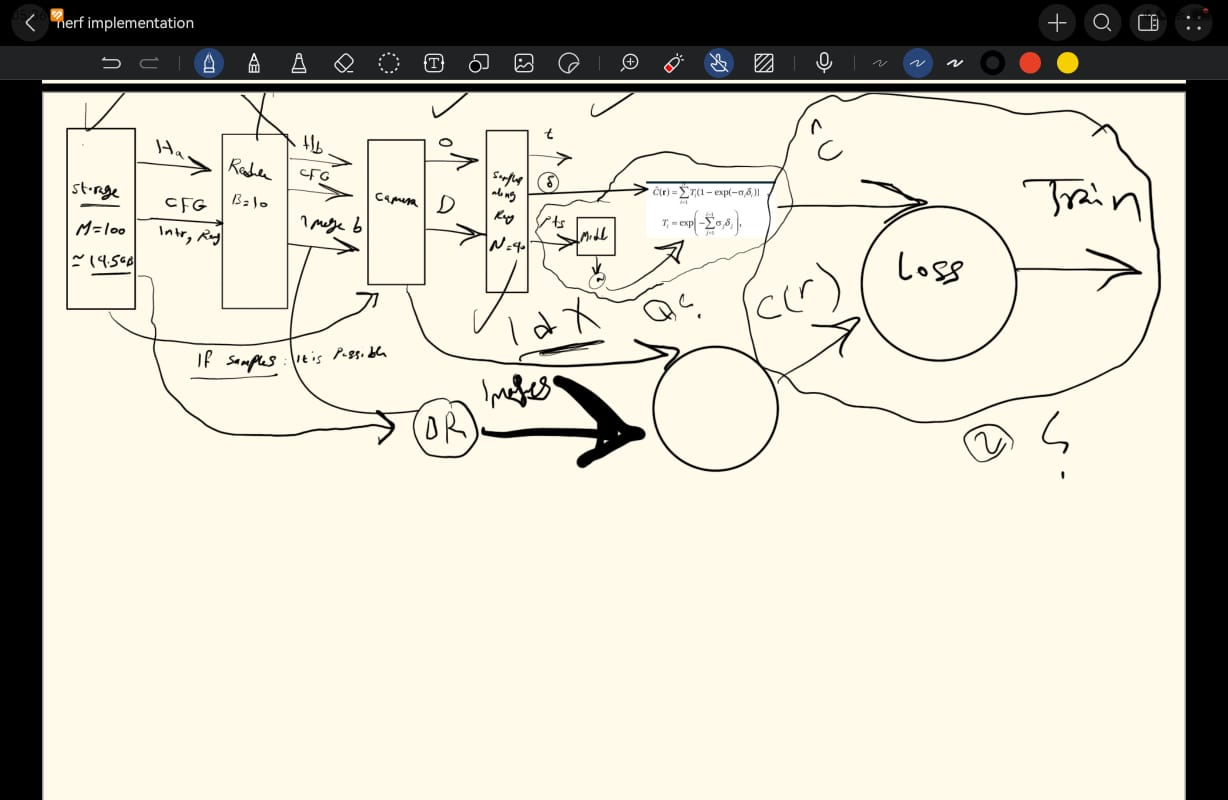

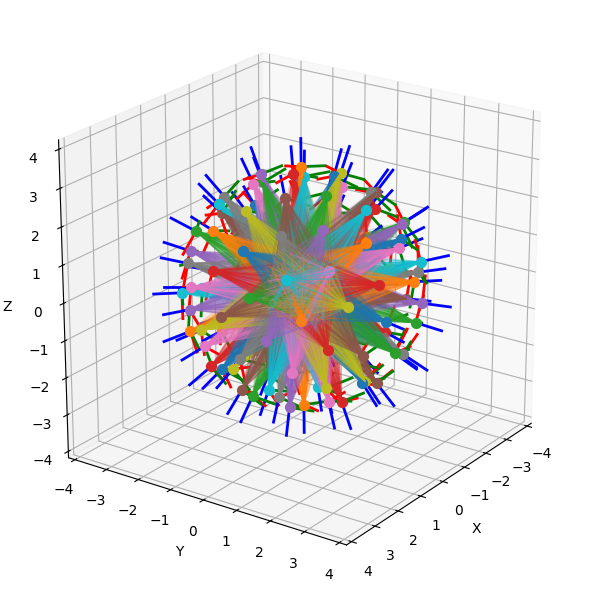

In [11]:

# ---- Optional: plot the world and selected camera ----
if show_world:
    try:
        world = load_world(world_json_path)
        cam = cam
        plot_world(
            world,
            cameras=cam,
            cam_indices='all',
            draw_rays=True,
            ray_mode="lines",
            rays_per_pose=100,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
        )
        plt.show()
    except Exception as e:
        print("World plot skipped due to error:", e)


In [12]:
class Tiny_Nerf(Module):
  def __init__(self, in_features = 3, out_features = 1, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.in_features = in_features # point (x, y, z)
    self.out_features = out_features # sigma scalar
    self.layers = Sequential(Linear(self.in_features, 64),
                             Linear(64, self.out_features),
                             Softplus())
  def forward(self, x):
    return self.layers(x).squeeze(-1)
  

TEST = True
if TEST:
  model = Tiny_Nerf()
  print(model.parameters)

  print(pts.shape)
  sigma = model(pts)
  print(sigma.shape)

<bound method Module.parameters of Tiny_Nerf(
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=1, bias=True)
    (2): Softplus(beta=1.0, threshold=20.0)
  )
)>
torch.Size([100, 4096, 40, 3])
torch.Size([100, 4096, 40])


In [13]:
C_hat = nerf_opacity(sigma, delta, full_output=False)
print(C_hat.shape)
print(C_true.shape)
print(C_hat)

torch.Size([100, 4096])
torch.Size([100, 4096])
tensor([[0.4604, 0.4578, 0.4572,  ..., 0.4605, 0.4568, 0.4601],
        [0.4606, 0.4598, 0.4558,  ..., 0.4591, 0.4596, 0.4602],
        [0.4561, 0.4611, 0.4620,  ..., 0.4598, 0.4639, 0.4589],
        ...,
        [0.4629, 0.4580, 0.4632,  ..., 0.4638, 0.4570, 0.4585],
        [0.4617, 0.4591, 0.4609,  ..., 0.4591, 0.4597, 0.4638],
        [0.4602, 0.4602, 0.4633,  ..., 0.4594, 0.4616, 0.4567]],
       grad_fn=<SumBackward1>)


In [14]:
print(mse_loss(C_hat, C_true))

tensor(0.2244, grad_fn=<MseLossBackward0>)
